In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sb
df=pd.read_csv('BRICS_Clean_Analysis_1990_2024.csv')
print(df.head(5))

  economy  Year  GDP_Current_USD  GDP_per_Capita_USD  GDP_Growth_Annual_Pct  \
0  Brazil  1990     3.907260e+11         2619.801411              -4.350000   
1  Brazil  1991     3.426090e+11         2258.104540               1.032190   
2  Brazil  1992     3.281880e+11         2127.290830              -0.544072   
3  Brazil  1993     3.682960e+11         2348.906354               4.924690   
4  Brazil  1994     5.253700e+11         3298.714919               5.852870   

        GDP_PPP  Total_Exports_USD  Total_Imports_USD  \
0  9.974580e+11       3.141400e+10       2.252200e+10   
1  1.041830e+12       3.162000e+10       2.294700e+10   
2  1.059780e+12       3.579300e+10       2.311600e+10   
3  1.138330e+12       3.855500e+10       2.760400e+10   
4  1.230680e+12       4.354500e+10       3.619200e+10   

   Household_Consumption_Growth  Urban_Population_Pct  Life_Expectancy_Years  \
0                     -0.940538             74.869901                 65.862   
1                     

In [2]:
sb.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)

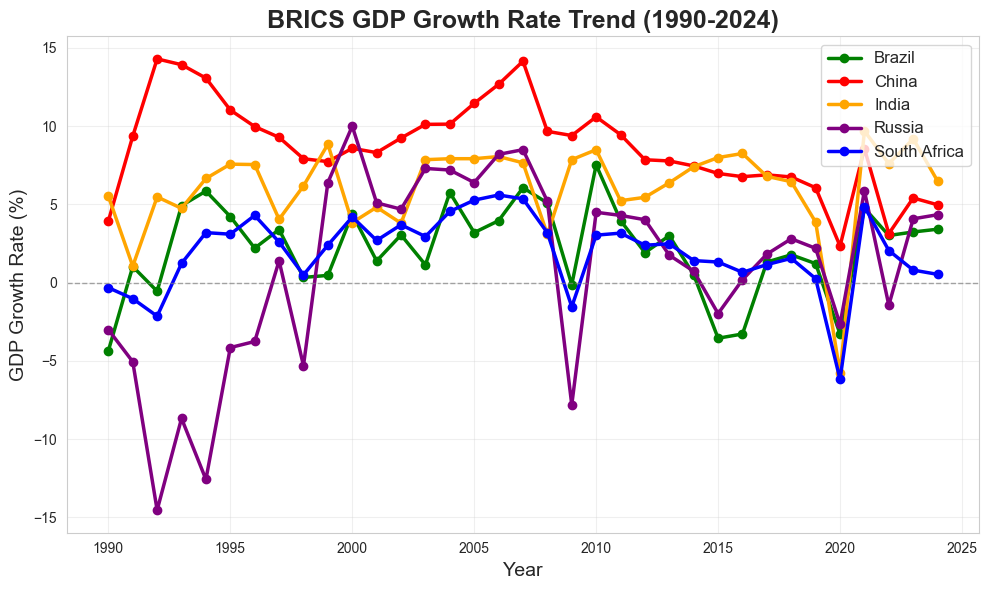

In [3]:

colors = {
    'Brazil': 'green',
    'China': 'red',
    'India': 'orange',
    'Russia': 'purple',
    'South Africa': 'blue'
}
for country in df['economy'].unique():
    subset=df[df['economy']==country]
    plt.plot(
        subset['Year'],
        subset['GDP_Growth_Annual_Pct'],
        marker='o',
        label=country,
        linewidth=2.5,
        color=colors[country])
plt.axhline(y=0,
            color='grey',
            linestyle='--',
            alpha=0.7,
            linewidth=1)
plt.title('BRICS GDP Growth Rate Trend (1990-2024)',fontsize=18,fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('GDP Growth Rate (%)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('BRICS_GDP_Growth_Trend.png', dpi=300, bbox_inches='tight')
plt.show()

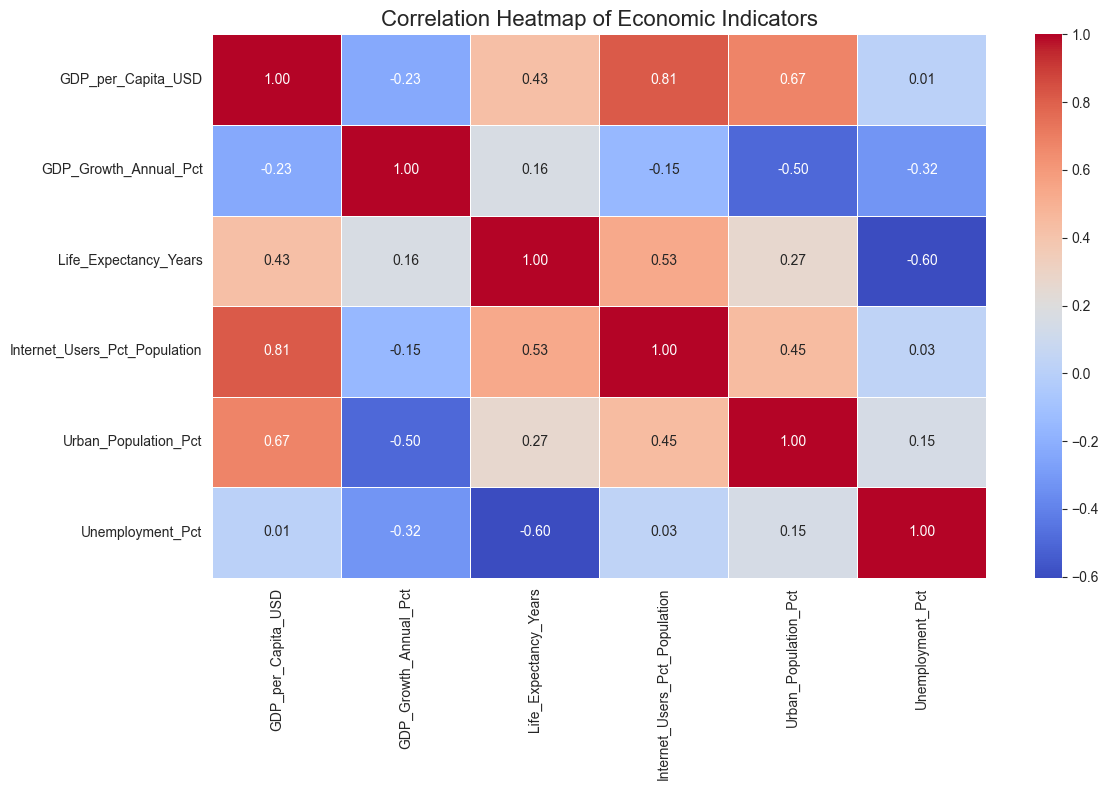

In [6]:
cols_for_corr = ['GDP_per_Capita_USD', 'GDP_Growth_Annual_Pct', 
                 'Life_Expectancy_Years', 'Internet_Users_Pct_Population', 
                 'Urban_Population_Pct', 'Unemployment_Pct']

available_cols = [col for col in cols_for_corr if col in df.columns]
corr_df = df[available_cols].corr()
plt.figure(figsize=(12, 8))
sb.heatmap(
    corr_df,
    annot=True,       
    cmap='coolwarm',   
    fmt='.2f',         
    linewidths=0.5
)

plt.title('Correlation Heatmap of Economic Indicators', fontsize=16)
plt.savefig('Correlation Heatmap of Economic Indicators.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

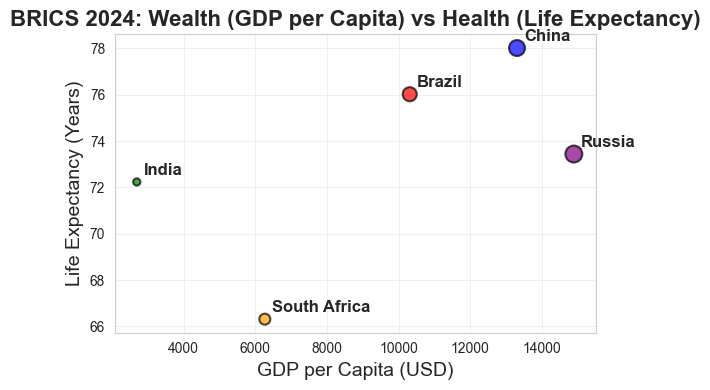

In [5]:
latest_2024 = df[df['Year'] == 2024]

plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    latest_2024['GDP_per_Capita_USD'], 
    latest_2024['Life_Expectancy_Years'],
    s=latest_2024['GDP_per_Capita_USD']/100,  
    c=['red', 'blue', 'green', 'purple', 'orange'],  
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)
for i, row in latest_2024.iterrows():
    plt.annotate(row['economy'], 
                 (row['GDP_per_Capita_USD'], row['Life_Expectancy_Years']),
                 fontsize=12, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')
plt.title('BRICS 2024: Wealth (GDP per Capita) vs Health (Life Expectancy)', fontsize=16, fontweight='bold')
plt.xlabel('GDP per Capita (USD)', fontsize=14)
plt.ylabel('Life Expectancy (Years)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('BRICS_Wealth_vs_Health_2024.png', dpi=300, bbox_inches='tight')
plt.show()